In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score

In [2]:
# Dataset Kaggle üzerinden alınmıştır.
# Projede lung_cancer_data.csv veri seti kullanılmıştır.

df = pd.read_csv("lung_cancer_data.csv")

print("Dataset Shape:", df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())

df = df.dropna()

print("Missing Values:", df.isnull().sum().sum())

print(df.describe())

Dataset Shape: (23658, 38)
    Patient_ID  Age  Gender Smoking_History  Tumor_Size_mm Tumor_Location  \
0  Patient0000   68    Male  Current Smoker      81.678677     Lower Lobe   
1  Patient0001   58    Male    Never Smoked      78.448272     Lower Lobe   
2  Patient0002   44    Male   Former Smoker      67.714305     Lower Lobe   
3  Patient0003   72    Male  Current Smoker      70.806008     Lower Lobe   
4  Patient0004   37  Female    Never Smoked      87.272433     Lower Lobe   

       Stage          Treatment  Survival_Months         Ethnicity  ...  \
0  Stage III            Surgery               44          Hispanic  ...   
1    Stage I  Radiation Therapy              101         Caucasian  ...   
2    Stage I       Chemotherapy               69  African American  ...   
3  Stage III       Chemotherapy               95  African American  ...   
4   Stage IV  Radiation Therapy              105             Asian  ...   

  Alanine_Aminotransferase_Level Aspartate_Aminotransferase

In [3]:
categorical_columns = df.select_dtypes(include=["object", "string"]).columns

label_encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

print(df.head())

# One-Hot Encoding uyguluyorum.
# Gender değişkeni üzerinde uygulanmıştır. Modelimi halen labelencoding girdisinden eğitiyorum

df_onehot = pd.get_dummies(
    df,
    columns=["Gender"],
    drop_first=True
)

print(df_onehot.head())

   Patient_ID  Age  Gender  Smoking_History  Tumor_Size_mm  Tumor_Location  \
0           0   68       1                0      81.678677               0   
1           1   58       1                2      78.448272               0   
2           2   44       1                1      67.714305               0   
3           3   72       1                0      70.806008               0   
4           4   37       0                2      87.272433               0   

   Stage  Treatment  Survival_Months  Ethnicity  ...  \
0      2          2               44          3  ...   
1      0          1              101          2  ...   
2      0          0               69          0  ...   
3      2          0               95          0  ...   
4      3          1              105          1  ...   

   Alanine_Aminotransferase_Level  Aspartate_Aminotransferase_Level  \
0                       27.985571                         46.801214   
1                       30.120956                   

In [4]:
# İlk başta Stage değişkenini hedef olarak seçtim fakat accuracy düşük çıktı.
# Bu yüzden hastanın durumunu daha genel temsil eden High_Risk adlı yeni bir target oluşturdum

df["High_Risk"] = np.where(
    (df["Performance_Status"] >= 3) | (df["Stage"].isin([2, 3])),
    1,
    0
)

print(df["High_Risk"].value_counts())

X = df.drop(
    ["High_Risk", "Patient_ID", "Stage", "Performance_Status"],
    axis=1
)

y = df["High_Risk"]

High_Risk
1    16616
0     7042
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# 5 adet modelimi eğitmeye başlıyorum. 
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# -- MODEL EVALUATION METRICS --
# Accuracy, Precision, Recall ve F1-score değerlerini tablo halinde hesaplıyorum.

results = []

for model_name, model in models.items():

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average="weighted")
    recall = recall_score(y_test, predictions, average="weighted")
    f1 = f1_score(y_test, predictions, average="weighted")

    results.append([
        model_name,
        acc,
        precision,
        recall,
        f1
    ])

    print(model_name)
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-Score:", f1)
    print("--------------------------------")

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print("\nMODEL EVALUATION RESULTS")
print(results_df)

C:\Users\xspjp\OneDrive\Masaüstü\Yeni klasör\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Logistic Regression
Accuracy: 0.7087912087912088
Precision: 0.5023849776597029
Recall: 0.7087912087912088
F1-Score: 0.5880004240132858
--------------------------------
Decision Tree
Accuracy: 0.5830515638207946
Precision: 0.590325906510321
Recall: 0.5830515638207946
F1-Score: 0.5865346143950224
--------------------------------
Random Forest
Accuracy: 0.7083685545224007
Precision: 0.6190317941270927
Recall: 0.7083685545224007
F1-Score: 0.5893537629966626
--------------------------------
KNN
Accuracy: 0.6363060016906171
Precision: 0.5825297239041665
Recall: 0.6363060016906171
F1-Score: 0.6008836501242579
--------------------------------
Gradient Boosting
Accuracy: 0.7068892645815723
Precision: 0.5285277103747767
Recall: 0.7068892645815723
F1-Score: 0.5874652023959609
--------------------------------

MODEL EVALUATION RESULTS
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.708791   0.502385  0.708791  0.588000
1        Decision Tree  0.583052   0.

In [7]:
# -- DEEP LEARNING MODELS --
# TensorFlow yerine sklearn MLPClassifier kullanarak 3 farklı yapay sinir ağı modeli kuruyorum. Çünkü araştırmalarıma göre TensorFlow python 3.14
# sürümünde stabil çalışmadı araştırmalarım sonucunda bu yolu değerlendiriyorum.

deep_learning_models = {
    "MLP Model 1": MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    ),
    "MLP Model 2": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    ),
    "MLP Model 3": MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    )
}

dl_results = []

for model_name, dl_model in deep_learning_models.items():

    dl_model.fit(X_train_scaled, y_train)

    dl_predictions = dl_model.predict(X_test_scaled)

    dl_acc = accuracy_score(y_test, dl_predictions)
    dl_precision = precision_score(y_test, dl_predictions, average="weighted")
    dl_recall = recall_score(y_test, dl_predictions, average="weighted")
    dl_f1 = f1_score(y_test, dl_predictions, average="weighted")

    dl_results.append([
        model_name,
        dl_acc,
        dl_precision,
        dl_recall,
        dl_f1
    ])

    print(model_name)
    print("Accuracy:", dl_acc)
    print("Precision:", dl_precision)
    print("Recall:", dl_recall)
    print("F1-Score:", dl_f1)
    print("--------------------------------")

dl_results_df = pd.DataFrame(
    dl_results,
    columns=["Deep Learning Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print("\nDEEP LEARNING MODEL RESULTS")
print(dl_results_df)

MLP Model 1
Accuracy: 0.6804733727810651
Precision: 0.5869875209219612
Recall: 0.6804733727810651
F1-Score: 0.6026924256436065
--------------------------------
MLP Model 2
Accuracy: 0.6079881656804734
Precision: 0.5958531554178645
Recall: 0.6079881656804734
F1-Score: 0.6014547500189568
--------------------------------
MLP Model 3
Accuracy: 0.5817836010143702
Precision: 0.5822300997805844
Recall: 0.5817836010143702
F1-Score: 0.5820063019598462
--------------------------------

DEEP LEARNING MODEL RESULTS
  Deep Learning Model  Accuracy  Precision    Recall  F1-Score
0         MLP Model 1  0.680473   0.586988  0.680473  0.602692
1         MLP Model 2  0.607988   0.595853  0.607988  0.601455
2         MLP Model 3  0.581784   0.582230  0.581784  0.582006


In [8]:
# -- ITERATIVE ENHANCEMENT FOR DEEP LEARNING --
# Deep learning modelinin accuracy değerini artırmak için farklı iterasyon sayıları ile deneme yapıyorum.

dl_enhancement_results = []

iteration_values = [300, 500, 1000]

for iteration in iteration_values:

    enhanced_mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation="relu",
        solver="adam",
        max_iter=iteration,
        random_state=42
    )

    enhanced_mlp.fit(X_train_scaled, y_train)

    enhanced_predictions = enhanced_mlp.predict(X_test_scaled)

    enhanced_accuracy = accuracy_score(y_test, enhanced_predictions)
    enhanced_precision = precision_score(
        y_test,
        enhanced_predictions,
        average="weighted",
        zero_division=0
    )
    enhanced_recall = recall_score(
        y_test,
        enhanced_predictions,
        average="weighted"
    )
    enhanced_f1 = f1_score(
        y_test,
        enhanced_predictions,
        average="weighted"
    )

    dl_enhancement_results.append([
        iteration,
        enhanced_accuracy,
        enhanced_precision,
        enhanced_recall,
        enhanced_f1
    ])

    print("Iteration:", iteration)
    print("Accuracy:", enhanced_accuracy)
    print("Precision:", enhanced_precision)
    print("Recall:", enhanced_recall)
    print("F1-Score:", enhanced_f1)
    print("--------------------------------")

dl_enhancement_df = pd.DataFrame(
    dl_enhancement_results,
    columns=[
        "Max Iteration",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

print("\nDEEP LEARNING ITERATIVE ENHANCEMENT RESULTS")
print(dl_enhancement_df)

Iteration: 300
Accuracy: 0.5817836010143702
Precision: 0.5822300997805844
Recall: 0.5817836010143702
F1-Score: 0.5820063019598462
--------------------------------
Iteration: 500
Accuracy: 0.5817836010143702
Precision: 0.5822300997805844
Recall: 0.5817836010143702
F1-Score: 0.5820063019598462
--------------------------------
Iteration: 1000
Accuracy: 0.5817836010143702
Precision: 0.5822300997805844
Recall: 0.5817836010143702
F1-Score: 0.5820063019598462
--------------------------------

DEEP LEARNING ITERATIVE ENHANCEMENT RESULTS
   Max Iteration  Accuracy  Precision    Recall  F1-Score
0            300  0.581784    0.58223  0.581784  0.582006
1            500  0.581784    0.58223  0.581784  0.582006
2           1000  0.581784    0.58223  0.581784  0.582006


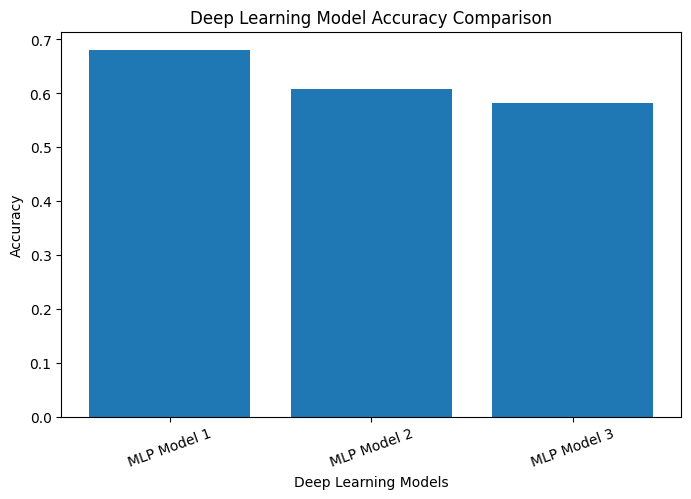

In [9]:
# Deep Learning Model Accuracy Graph yazdırıyorum.

plt.figure(figsize=(8,5))

plt.bar(
    dl_results_df["Deep Learning Model"],
    dl_results_df["Accuracy"]
)

plt.title("Deep Learning Model Accuracy Comparison")

plt.xlabel("Deep Learning Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

Logistic Regression
Cross Validation Accuracy Mean: 0.7007291551087543
Cross Validation Accuracy Std: 0.00010245686790698366
--------------------------------
Decision Tree
Cross Validation Accuracy Mean: 0.5780938464104353
Cross Validation Accuracy Std: 0.007226277414221905
--------------------------------
Random Forest
Cross Validation Accuracy Mean: 0.6997252060535896
Cross Validation Accuracy Std: 0.0003888206308635864
--------------------------------
KNN
Cross Validation Accuracy Mean: 0.6410228883301546
Cross Validation Accuracy Std: 0.005677438770690952
--------------------------------
Gradient Boosting
Cross Validation Accuracy Mean: 0.6998309142840793
Cross Validation Accuracy Std: 0.0005149143513246648
--------------------------------


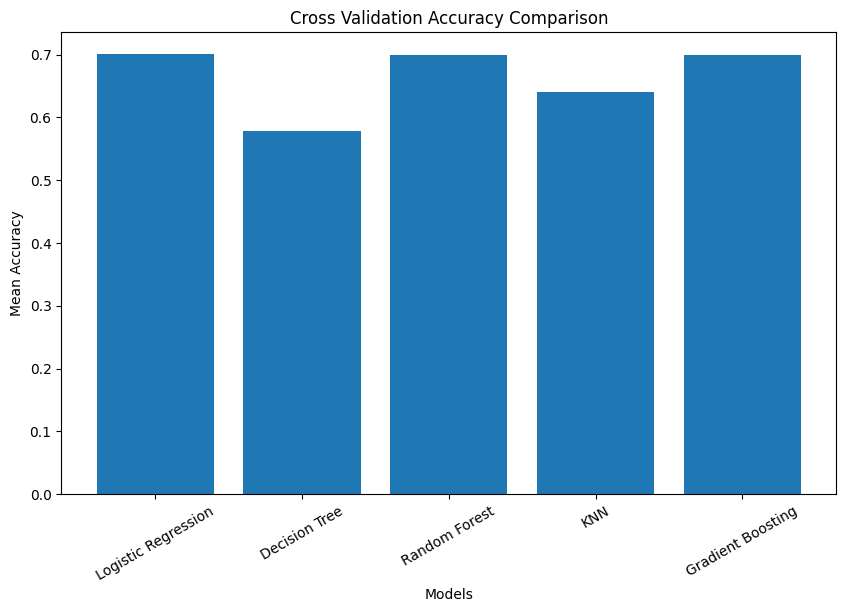


CROSS VALIDATION RESULTS
                 Model  CV Accuracy Mean  CV Accuracy Std
0  Logistic Regression          0.700729         0.000102
1        Decision Tree          0.578094         0.007226
2        Random Forest          0.699725         0.000389
3                  KNN          0.641023         0.005677
4    Gradient Boosting          0.699831         0.000515


In [10]:
# -- CROSS VALIDATION --
# Modellerin genelleme başarısını daha güvenilir ölçmek için 5-fold cross validation uyguluyorum.

cv_results = []

for model_name, model in models.items():

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append([
        model_name,
        scores.mean(),
        scores.std()
    ])

    print(model_name)
    print("Cross Validation Accuracy Mean:", scores.mean())
    print("Cross Validation Accuracy Std:", scores.std())
    print("--------------------------------")

cv_df = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "CV Accuracy Mean",
        "CV Accuracy Std"
    ]
)

# Cross Validation Accuracy Grafiği ekliyorum.

plt.figure(figsize=(10,6))

plt.bar(
    cv_df["Model"],
    cv_df["CV Accuracy Mean"]
)

plt.title("Cross Validation Accuracy Comparison")

plt.xlabel("Models")
plt.ylabel("Mean Accuracy")

plt.xticks(rotation=30)

plt.show()

print("\nCROSS VALIDATION RESULTS")
print(cv_df)

Logistic Regression
Training Time: 0.037993669509887695
Single Record Prediction Time: 0.0008819103240966797
Single Record Prediction: 1
--------------------------------
Decision Tree
Training Time: 1.2863032817840576
Single Record Prediction Time: 0.0003619194030761719
Single Record Prediction: 1
--------------------------------
Random Forest
Training Time: 11.481411457061768
Single Record Prediction Time: 0.012955188751220703
Single Record Prediction: 1
--------------------------------
KNN
Training Time: 0.004354000091552734
Single Record Prediction Time: 0.0044040679931640625
Single Record Prediction: 1
--------------------------------
Gradient Boosting
Training Time: 18.600737810134888
Single Record Prediction Time: 0.0005753040313720703
Single Record Prediction: 1
--------------------------------

TRAINING AND PREDICTION TIME RESULTS
                 Model  Training Time (sec)  Single Prediction Time (sec)  \
0  Logistic Regression             0.037994                      0.00088

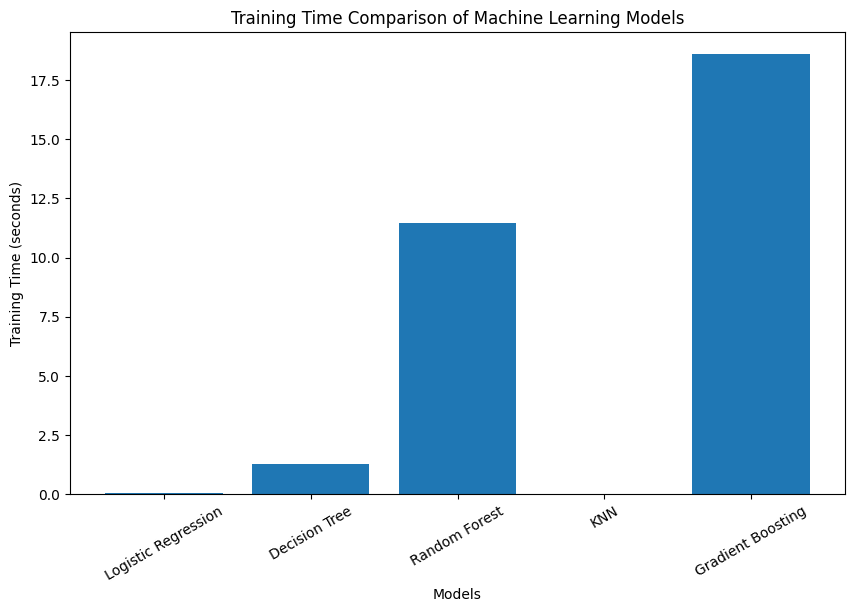

In [11]:
# -- TRAINING TIME VE SINGLE RECORD PREDICTION TIME --
# Her model için eğitim süresini ve tek bir veri için tahmin süresini ölçüyorum.

time_results = []

single_record = X_test_scaled[0].reshape(1, -1)

for model_name, model in models.items():

    start_train = time.time()

    model.fit(X_train_scaled, y_train)

    end_train = time.time()

    training_time = end_train - start_train

    start_pred = time.time()

    single_prediction = model.predict(single_record)

    end_pred = time.time()

    prediction_time = end_pred - start_pred

    time_results.append([
        model_name,
        training_time,
        prediction_time,
        single_prediction[0]
    ])

    print(model_name)
    print("Training Time:", training_time)
    print("Single Record Prediction Time:", prediction_time)
    print("Single Record Prediction:", single_prediction[0])
    print("--------------------------------")

time_df = pd.DataFrame(
    time_results,
    columns=[
        "Model",
        "Training Time (sec)",
        "Single Prediction Time (sec)",
        "Single Prediction"
    ]
)

print("\nTRAINING AND PREDICTION TIME RESULTS")
print(time_df)


# Training Time Comparison Graph ekliyorum.

plt.figure(figsize=(10,6))

plt.bar(
    time_df["Model"],
    time_df["Training Time (sec)"]
)

plt.title("Training Time Comparison of Machine Learning Models")

plt.xlabel("Models")
plt.ylabel("Training Time (seconds)")

plt.xticks(rotation=30)

plt.show()

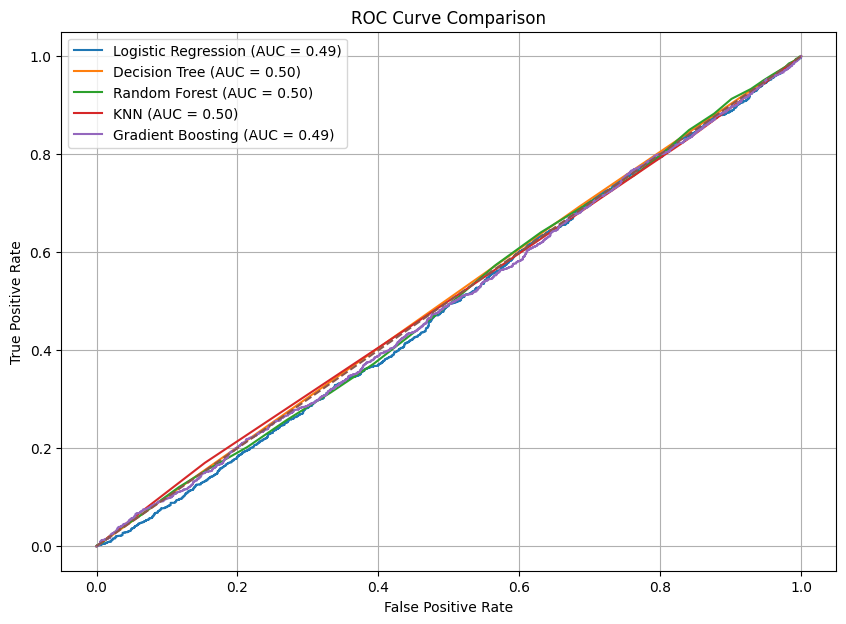


AUC RESULTS
                 Model       AUC
0  Logistic Regression  0.488916
1        Decision Tree  0.503862
2        Random Forest  0.497170
3                  KNN  0.502080
4    Gradient Boosting  0.494241


In [12]:
# -- ROC CURVE VE AUC DEĞERLERİ --
# Modellerin sınıfları ayırt etme başarısını ROC eğrisi ve AUC değeri ile inceliyorum.

plt.figure(figsize=(10, 7))

auc_results = []

for model_name, model in models.items():

    model.fit(X_train_scaled, y_train)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob = model.decision_function(X_test_scaled)

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    auc_results.append([
        model_name,
        roc_auc
    ])

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {roc_auc:.2f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()

plt.show()

auc_df = pd.DataFrame(
    auc_results,
    columns=["Model", "AUC"]
)

print("\nAUC RESULTS")
print(auc_df)

In [13]:
# List Parameters of Used Algorithms
parameter_table = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "Gradient Boosting"
    ],
    "Parameters":[
        "max_iter=5000",
        "random_state=42",
        "random_state=42",
        "default",
        "random_state=42"
    ]
})

print(parameter_table)


#-- Daha anlaşılır olması için Normalizasyon öncesi ve sonrası tablomu yazdırıyorum. --

# NORMALİZASYON ÖNCESİ : 

print("\nNORMALIZATION BEFORE")

before_results = []

for model_name, model in models.items():

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    acc = accuracy_score(y_test, predictions)

    before_results.append([model_name, acc])

    print(model_name, "Accuracy:", acc)

# NORMALİZASYON SONRASI : 

print("\nNORMALIZATION AFTER")

after_results = []

for model_name, model in models.items():

    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, predictions)

    after_results.append([model_name, acc])

    print(model_name, "Accuracy:", acc)

comparison_df = pd.DataFrame({
    "Model": [x[0] for x in before_results],
    "Before_Normalization": [x[1] for x in before_results],
    "After_Normalization": [x[1] for x in after_results]
})

print("\nMODEL COMPARISON")
print(comparison_df)

                 Model       Parameters
0  Logistic Regression    max_iter=5000
1        Decision Tree  random_state=42
2        Random Forest  random_state=42
3                  KNN          default
4    Gradient Boosting  random_state=42

NORMALIZATION BEFORE
Logistic Regression Accuracy: 0.7087912087912088
Decision Tree Accuracy: 0.5832628909551987
Random Forest Accuracy: 0.7092138630600169
KNN Accuracy: 0.6346153846153846
Gradient Boosting Accuracy: 0.7068892645815723

NORMALIZATION AFTER
Logistic Regression Accuracy: 0.7087912087912088
Decision Tree Accuracy: 0.5830515638207946
Random Forest Accuracy: 0.7083685545224007
KNN Accuracy: 0.6363060016906171
Gradient Boosting Accuracy: 0.7068892645815723

MODEL COMPARISON
                 Model  Before_Normalization  After_Normalization
0  Logistic Regression              0.708791             0.708791
1        Decision Tree              0.583263             0.583052
2        Random Forest              0.709214             0.708369
3    


SMOTE BEFORE / AFTER COMPARISON
Confusion Matrix Before SMOTE:
[[   4 1374]
 [   6 3348]]
Classification Report Before SMOTE:
              precision    recall  f1-score   support

           0       0.40      0.00      0.01      1378
           1       0.71      1.00      0.83      3354

    accuracy                           0.71      4732
   macro avg       0.55      0.50      0.42      4732
weighted avg       0.62      0.71      0.59      4732

Before SMOTE class distribution:
High_Risk
1    13262
0     5664
Name: count, dtype: int64
After SMOTE class distribution:
High_Risk
0    13262
1    13262
Name: count, dtype: int64
Confusion Matrix After SMOTE:
[[  15 1363]
 [  43 3311]]
Classification Report After SMOTE:
              precision    recall  f1-score   support

           0       0.26      0.01      0.02      1378
           1       0.71      0.99      0.82      3354

    accuracy                           0.70      4732
   macro avg       0.48      0.50      0.42      4732
w

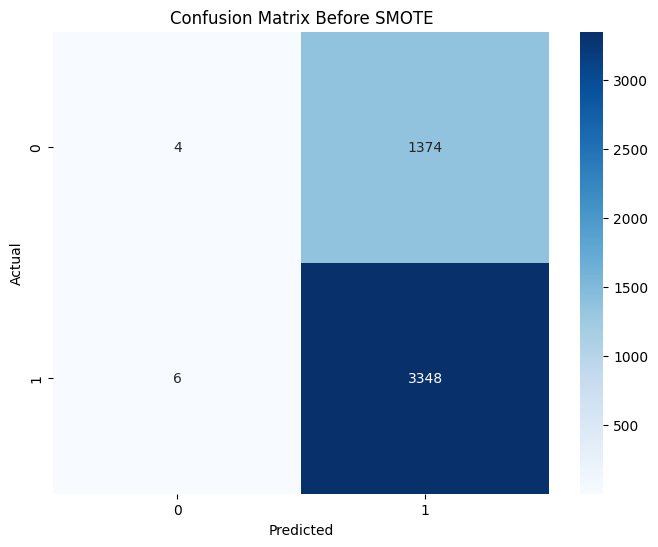

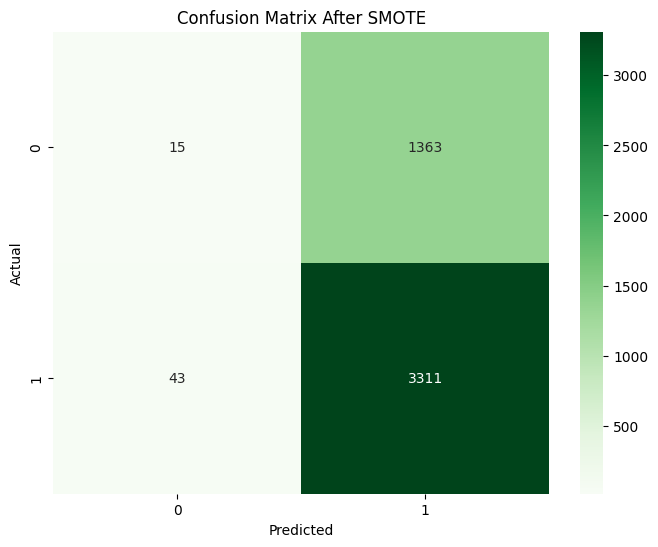

In [15]:
# -- SMOTE İLE DATA BALANCING --
# En iyi model Random Forest olduğu için SMOTE karşılaştırmasını Random Forest ile yapıyorum.

print("\nSMOTE BEFORE / AFTER COMPARISON")

best_model_before_smote = RandomForestClassifier(random_state=42)

best_model_before_smote.fit(X_train_scaled, y_train)

y_pred_before_smote = best_model_before_smote.predict(X_test_scaled)

cm_before_smote = confusion_matrix(y_test, y_pred_before_smote)

print("Confusion Matrix Before SMOTE:")
print(cm_before_smote)

print("Classification Report Before SMOTE:")
print(classification_report(y_test, y_pred_before_smote))


# SMOTE sadece train datasına uygulanır. Test datasına uygulanamaz.

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE class distribution:")
print(y_train.value_counts())

print("After SMOTE class distribution:")
print(pd.Series(y_train_smote).value_counts())


best_model_after_smote = RandomForestClassifier(random_state=42)

best_model_after_smote.fit(X_train_smote, y_train_smote)

y_pred_after_smote = best_model_after_smote.predict(X_test_scaled)

cm_after_smote = confusion_matrix(y_test, y_pred_after_smote)

print("Confusion Matrix After SMOTE:")
print(cm_after_smote)

print("Classification Report After SMOTE:")
print(classification_report(y_test, y_pred_after_smote))


# Confusion Matrix Before SMOTE grafiği

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_before_smote,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix Before SMOTE")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# Confusion Matrix After SMOTE grafiği

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_after_smote,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Confusion Matrix After SMOTE")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


TARGET DISTRIBUTION


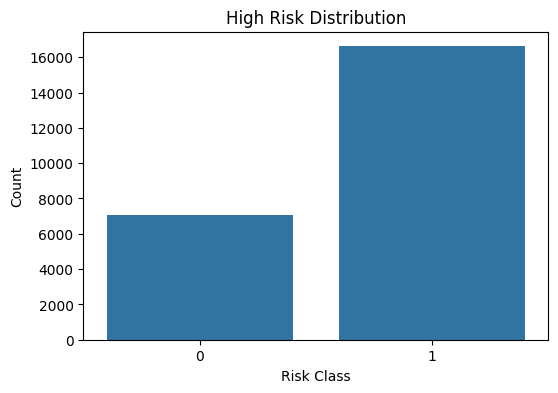


FEATURE DISTRIBUTIONS


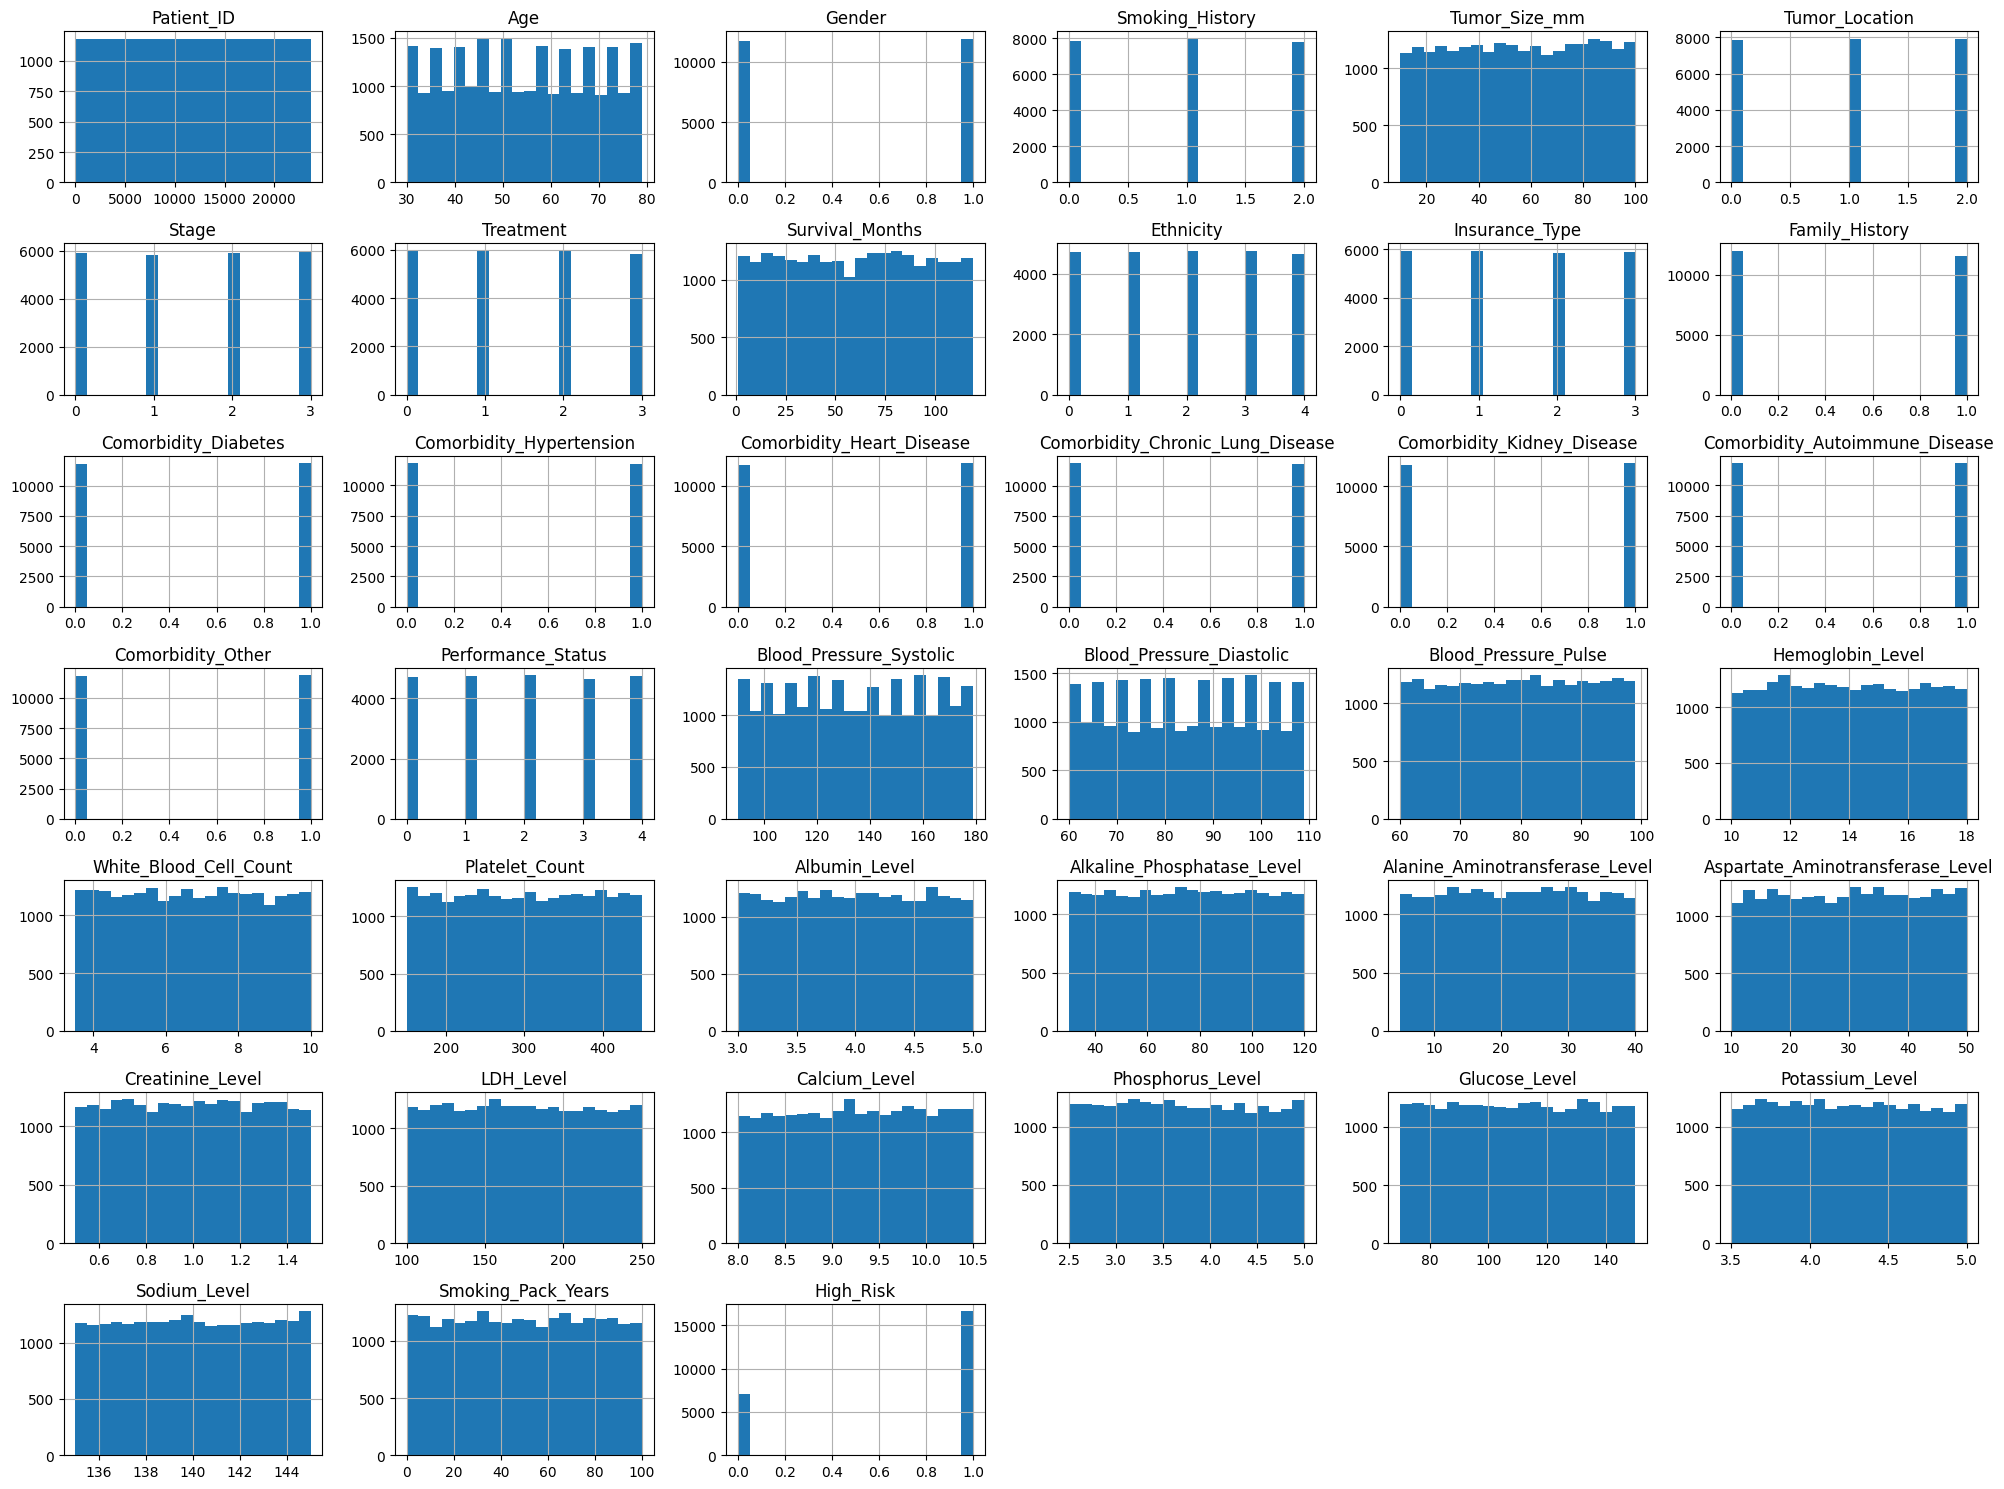


CORRELATION HEATMAP


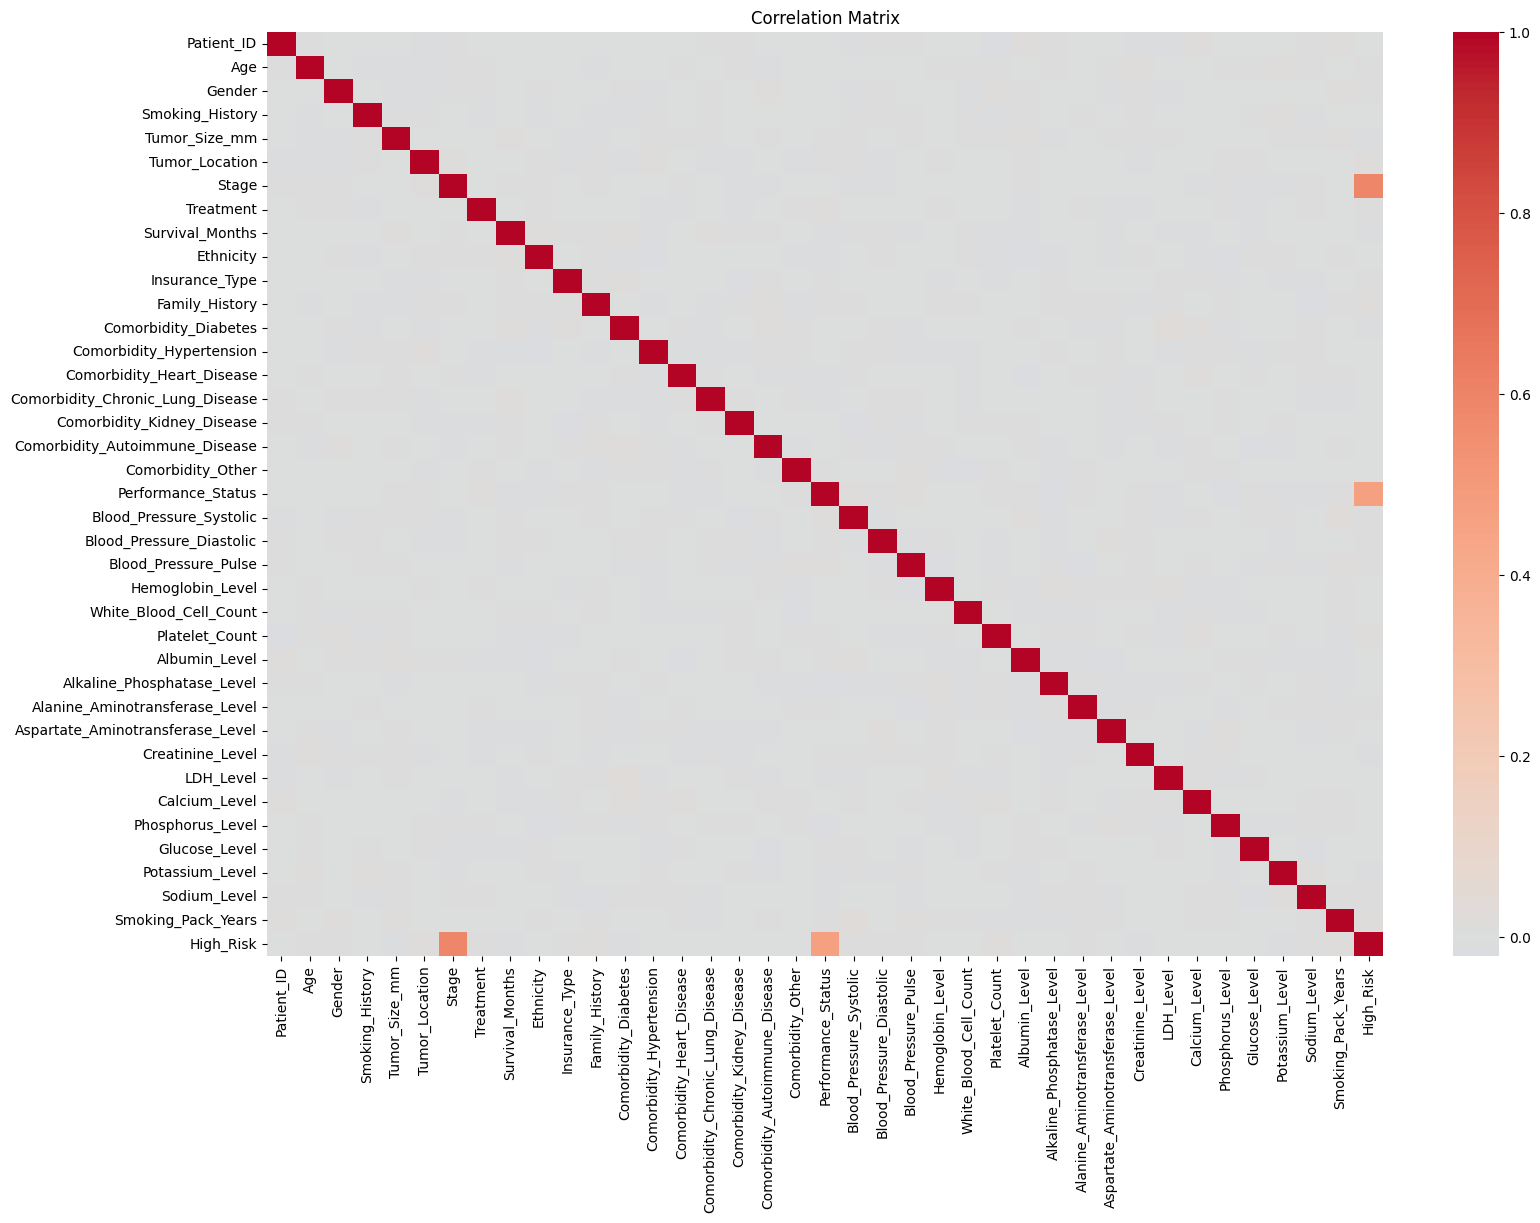


BOXPLOT


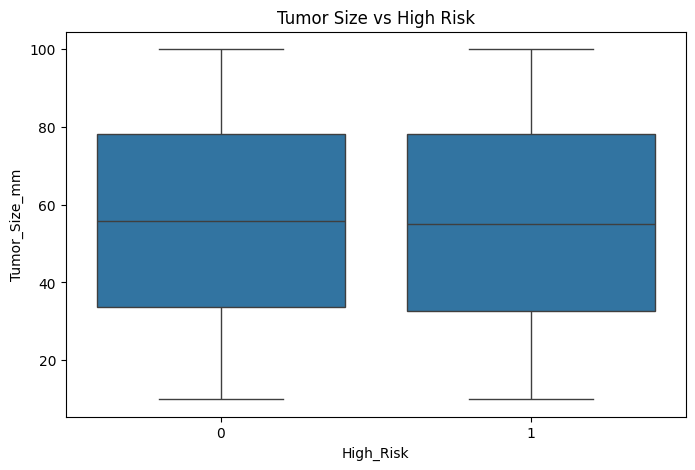


MODEL ACCURACY GRAPH


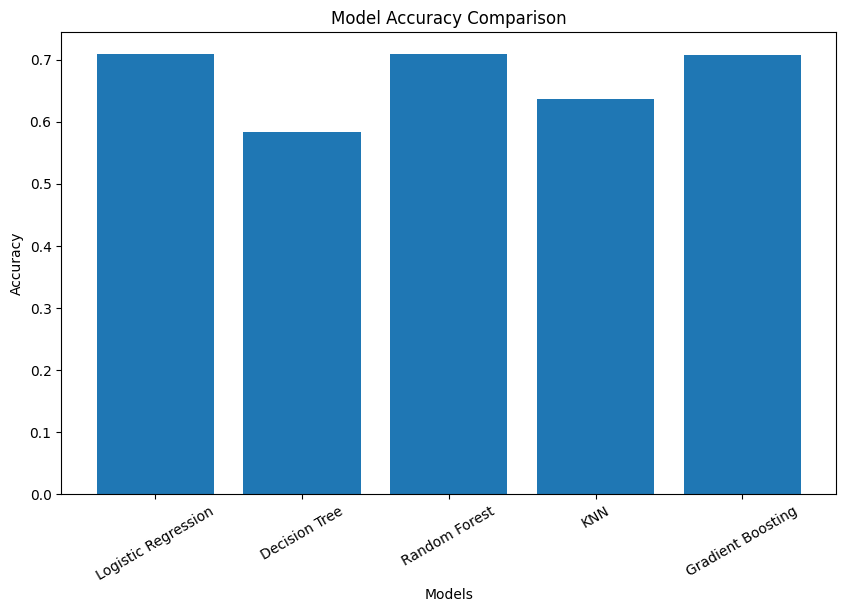

In [16]:
#-- Target dağılımı grağini oluşturuyorum.--
#  
print("\nTARGET DISTRIBUTION")

plt.figure(figsize=(6,4))

sns.countplot(
    x="High_Risk",
    data=df
)

plt.title("High Risk Distribution")
plt.xlabel("Risk Class")
plt.ylabel("Count")

plt.show()


# Feature Distribution - Tüm Sütunların Grafiği

print("\nFEATURE DISTRIBUTIONS")

df.hist(
    figsize=(20,15),
    bins=20
)

plt.tight_layout()

plt.show()

# Correlation Heatmap Grafiğini Alıyorum.

print("\nCORRELATION HEATMAP")

plt.figure(figsize=(18,12))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

# Boxplot Tumor Size Grafiği

print("\nBOXPLOT")

plt.figure(figsize=(8,5))

sns.boxplot(
    x="High_Risk",
    y="Tumor_Size_mm",
    data=df
)

plt.title("Tumor Size vs High Risk")

plt.show()

# Model Accuracy  Comparison Grafiği 

print("\nMODEL ACCURACY GRAPH")

plt.figure(figsize=(10,6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.show()

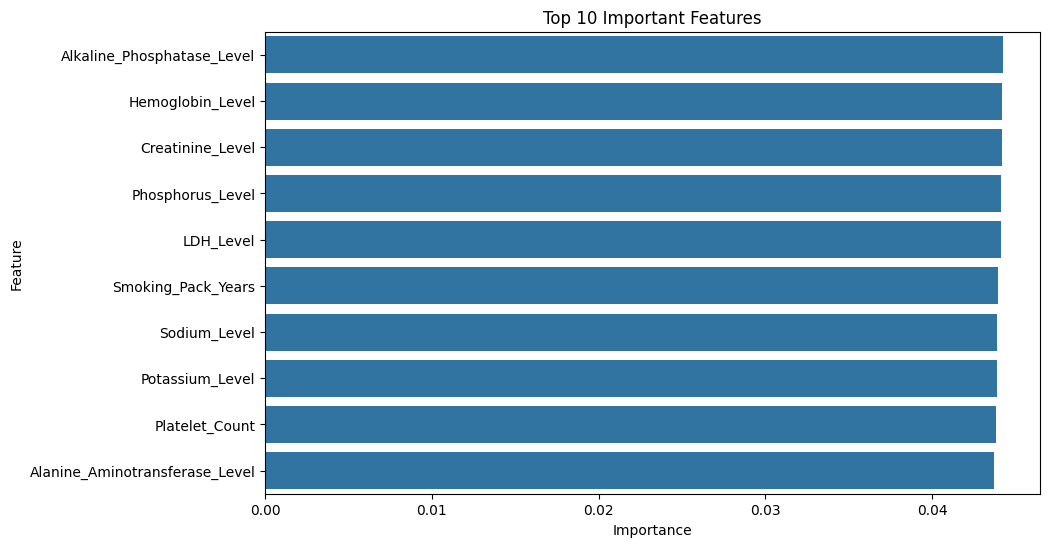


SELECTED FEATURES
['Alkaline_Phosphatase_Level', 'Hemoglobin_Level', 'Creatinine_Level', 'Phosphorus_Level', 'LDH_Level', 'Smoking_Pack_Years', 'Sodium_Level', 'Potassium_Level', 'Platelet_Count', 'Alanine_Aminotransferase_Level']

FEATURE SELECTION ACCURACY
Accuracy with Top 10 Features: 0.7047759932375317

FEATURE SELECTION COMPARISON
     Model Version  Accuracy
0     All Features  0.708369
1  Top 10 Features  0.704776


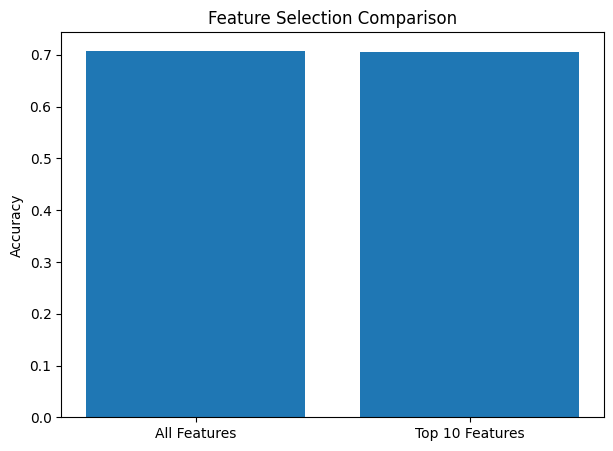

In [17]:
# -- FEATURE IMPORTANCE GRAFİĞİ --
# Random Forest'i tekrar eğitiyorum.
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_scaled, y_train)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Random Foresti tekrar eğittikten sonra grafiği alıyorum.
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

# -- FEATURE SELECTION --
# Random Forest importance skorlarına göre en önemli 10 özelliği seçiyorum.

selected_features = importance_df.head(10)["Feature"].tolist()

print("\nSELECTED FEATURES")
print(selected_features)

X_selected = X[selected_features]

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42
)

scaler_sel = StandardScaler()

X_train_sel = scaler_sel.fit_transform(X_train_sel)
X_test_sel = scaler_sel.transform(X_test_sel)

rf_selected = RandomForestClassifier(random_state=42)

rf_selected.fit(X_train_sel, y_train_sel)

y_pred_sel = rf_selected.predict(X_test_sel)

selected_accuracy = accuracy_score(
    y_test_sel,
    y_pred_sel
)

print("\nFEATURE SELECTION ACCURACY")
print("Accuracy with Top 10 Features:", selected_accuracy)

# Karşılaştırma Tablosunu yapıyorum. 

full_accuracy = results_df.loc[
    results_df["Model"] == "Random Forest",
    "Accuracy"
].values[0]


feature_selection_df = pd.DataFrame({
    "Model Version": [
        "All Features",
        "Top 10 Features"
    ],
    "Accuracy": [
        full_accuracy,
        selected_accuracy
    ]
})

print("\nFEATURE SELECTION COMPARISON")
print(feature_selection_df)


# Grafiği de ekliyorum. 
plt.figure(figsize=(7,5))

plt.bar(
    feature_selection_df["Model Version"],
    feature_selection_df["Accuracy"]
)

plt.title("Feature Selection Comparison")

plt.ylabel("Accuracy")

plt.show()

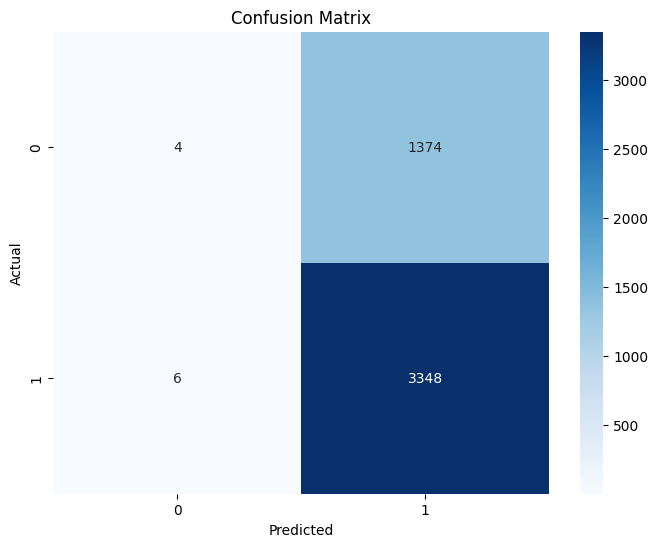

In [18]:
# Confusion Matrix Grafiğini alıyorum. 
best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
# -- MODEL SAVE --

joblib.dump(
    rf_model,
    "random_forest_model.pkl"
)

print("Model saved successfully.")


# -- MODEL LOAD --

loaded_model = joblib.load(
    "random_forest_model.pkl"
)

print("Model loaded successfully.")


sample_prediction = loaded_model.predict(
    X_test_scaled[:1]
)

print(
    "Prediction from loaded model:",
    sample_prediction[0]
)

# SONUÇ ---
# Random Forest modeli %70.92 doğruluk oranı ile en başarılı model olmuştur.

Model saved successfully.
Model loaded successfully.
Prediction from loaded model: 1
